In [1]:
from RiskMetrics.conformal_prediction import generate_returns, backtest_model, HistoricalVaR, ParametricVaR, EWMAVaR, ConformalPIDPredictor, AdaptiveConformalInference
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
np.random.seed(42)
returns_regime = generate_returns(n=2520, regime_changes=True, seasonality=True)

train_size = 250
alpha = 0.05
all_results = {}
all_details = {}

models = {
    'Historical VaR':HistoricalVaR(window_size=train_size),
    'Parametric VaR':ParametricVaR(window_size=train_size),
    'EWMA VaR':EWMAVaR(decay_factor=0.94, window_size=train_size),
    'Conformal P':ConformalPIDPredictor(window_size=train_size, learning_rate=0.1, use_integrator=False, use_scorecaster=False),
    'Conformal PI':ConformalPIDPredictor(window_size=train_size, learning_rate=0.1, use_integrator=True, use_scorecaster=False),
    'Conformal PID':ConformalPIDPredictor(window_size=train_size, learning_rate=0.1, use_integrator=True, use_scorecaster=True),
    'Conformal ACI':AdaptiveConformalInference(window_size=train_size, learning_rate=0.005, target_alpha=alpha),
}

print("\n" + "=" * 70)
print("RUN BACKTEST COMPARISON")
print(f"Target Coverage: {(1 - alpha) * 100}%")
print("=" * 70)

# Run Models
for model_name, model in models.items():
    print(f"\n Running {model_name}")
    all_results[model_name], all_details[model_name] = backtest_model(model, returns_regime, train_size=train_size, alpha=alpha, model_name=model_name)
    print(f"Coverage: {all_results[model_name].coverage:.3f}")

print("\n" + "=" * 70)
print("BACKTEST COMPLETE")
print("=" * 70)


RUN BACKTEST COMPARISON
Target Coverage: 95.0%

 Running Historical VaR
Coverage: 0.886

 Running Parametric VaR
Coverage: 0.910

 Running EWMA VaR
Coverage: 0.899

 Running Conformal P
Coverage: 0.950

 Running Conformal PI
Coverage: 0.950

 Running Conformal PID
Coverage: 0.863

 Running Conformal ACI
Coverage: 0.950

BACKTEST COMPLETE


In [ ]:
# CREATE SUMMARY TABLE
summary_data = []
for name, result in all_results.items():
    summary_data.append({
        'Method': name,
        'Coverage': f"{result.coverage:.1%}",
        'Target': f'{result.target_coverage:.1%}',
        'Coverage Gap': f'{(result.coverage - result.target_coverage) * 100:+.1f}%',
        'Violations': result.violations,
        'Average Width': f'{result.avg_interval_width:.4f}',
        'Kupiec p-value': f'{result.kupiec_pvalue:.3f}',
        'Christoff. p-value': f'{result.conditional_coverage_pvalue:.3f}'
    })

summary_df = pd.DataFrame(summary_data)
print('\n' + summary_df.to_string(index=False))


        Method Coverage Target Coverage Gap  Violations Average Width Kupiec p-value Christoff. p-value
Historical VaR    88.6%  95.0%        -6.4%         258        0.1207          0.000              0.000
Parametric VaR    91.0%  95.0%        -4.0%         204        0.1302          0.000              0.000
      EWMA VaR    89.9%  95.0%        -5.1%         230        0.1246          0.000              0.000
   Conformal P    95.0%  95.0%        -0.0%         114        0.2040          0.962              1.000
  Conformal PI    95.0%  95.0%        -0.0%         114        0.2043          0.962              1.000
 Conformal PID    86.3%  95.0%        -8.7%         312        0.1059          0.000              0.000
 Conformal ACI    95.0%  95.0%        +0.0%         113        0.1601          0.962              0.000


In [15]:
# COVERAGE COMPARISON BAR CHART

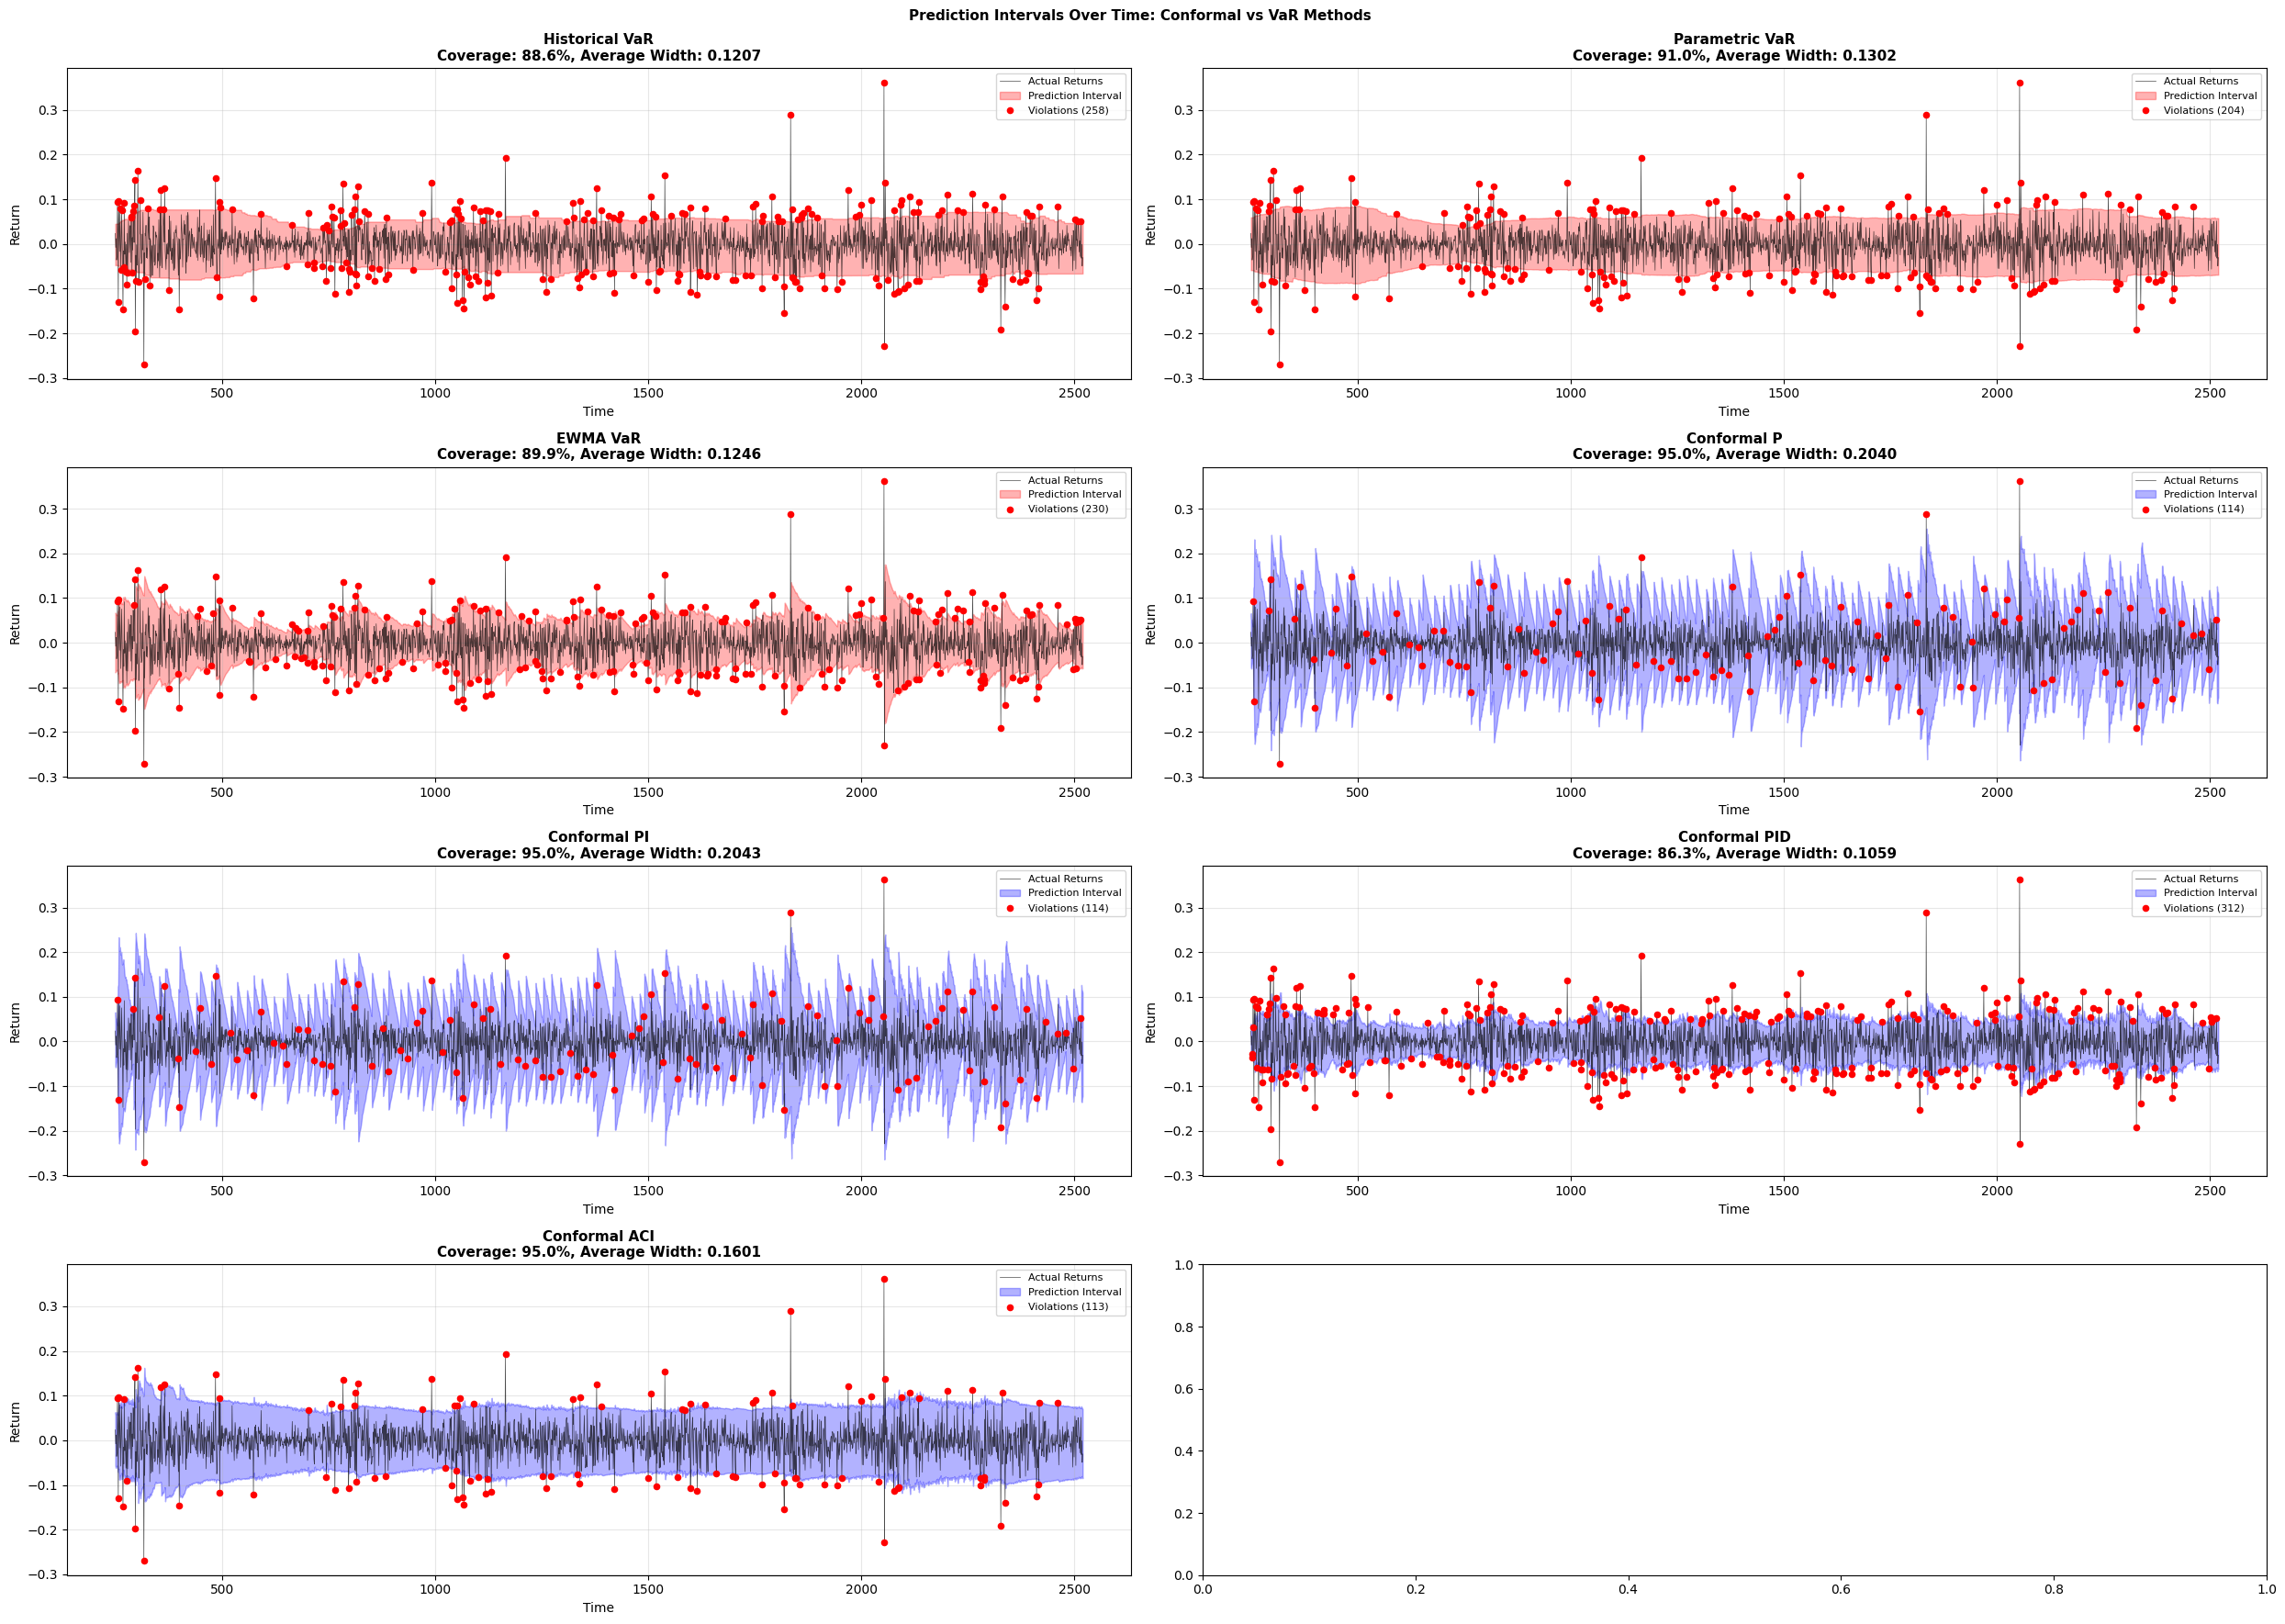

In [ ]:
# TIME SERIES OF PREDICTION INTERVALS

fig, axes = plt.subplots(4,2,figsize=(25,18))
methods_to_plot = list(models.keys())

for idx, method in enumerate(methods_to_plot):
    ax = axes[idx // 2, idx % 2]
    df = all_details[method]

    # Plot actual returns
    ax.plot(df['time'], df['actual'], 'k-', linewidth=0.5, alpha=0.7, label='Actual Returns')

    # Plot Prediction interval
    ax.fill_between(df['time'], df['lower'], df['upper'], alpha=0.3, color='blue' if 'Conformal' in method or method == 'ACI' else 'red', label = 'Prediction Interval')

    # mark breaches
    violations_df = df[df['violation']==True]
    ax.scatter(violations_df['time'], violations_df['actual'], color='red', s=20, zorder=5, label=f'Violations ({len(violations_df)})')

    ax.set_title(f'{method}\nCoverage: {all_results[method].coverage:.1%}, '
                 f'Average Width: {all_results[method].avg_interval_width:.4f}',
                 fontsize=11, fontweight='bold')

    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel('Return', fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Prediction Intervals Over Time: Conformal vs VaR Methods \n', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

